In [1]:
# load drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from textblob import TextBlob
import re
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go

In [3]:
articles = pd.read_csv('/content/drive/MyDrive/Playground/sa_news/data/articles.csv')
articles.head()

,date,title
0,2013-02-01,street life thats why im on the streets
1,2013-02-01,israeli elections the bizarre payoffs of bibis...
2,2009-10-12,Chad oil pipeline threatens villages draws act...
3,2009-10-12,Ethiopian opposition parties present common front
4,2009-10-12,Nigerian fuel tanker inferno engulfs minibus p...


In [4]:
# Normalise datatime format
articles['date'] = pd.to_datetime(articles['date'])
articles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118482 entries, 0 to 118481
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    118482 non-null  datetime64[ns]
 1   title   118482 non-null  object        
dtypes: datetime64[ns](1), object(1)
memory usage: 1.8+ MB


In [5]:
# headline text cleaning function

nltk.download('stopwords')
from nltk.corpus import stopwords

def clean_text(text):
    text = text.lower()  # lowercase
    text = text.encode('ascii', 'ignore').decode()  # remove non-ASCII characters
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation and numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra whitespace
    return text


def remove_stopwords(text):
    text = text.lower()  # lowercase
    text = text.encode('ascii', 'ignore').decode()  # remove non-ASCII characters
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation and numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra whitespace
    # Remove English and Afrikaans stop words
    stop_words = set(stopwords.words('english'))
    # Add Afrikaans stop words

    af_stopwords = set([

        'die', 'en', 'van', 'ek', 'jy', 'hy', 'sy', 'ons', 'julle', 'hulle',
        'my', 'jou', 'sy', 'haar', 'ons', 'julle', 'hulle', 'dit', 'wat', 'wie',
        'waar', 'wanneer', 'hoekom', 'hoe', 'is', 'was', 'sal', 'kan', 'moet',
        'nie', 'in', 'op', 'met', 'as', 'vir', 'aan', 'by', 'uit', 'oor', 'tot',
        'maar', 'of', 'want', 'dat', 'om', 'so', 'nog', 'al', 'baie', 'elke',
        'meer', 'min', 'self', 'sommige', 'sulke', 'sy', 'haar', 'hul', 'ons',
        'julle', 'hulle', 'hierdie', 'daardie', 'hier', 'daar', 'nou', 'toe',
        'vandaan', 'waarheen', 'waarvandaan', 'waarom', 'hoe', 'wanneer', 'waar',
        'wie', 'wat', 'waarom', 'hoe', 'wanneer', 'waar', 'wie', 'wat'
    ])
    stop_words = stop_words.union(af_stopwords)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# Apply text cleaning
articles['title'] = articles['title'].apply(clean_text)
articles['title_nw'] = articles['title'].apply(remove_stopwords)
articles.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,date,title,title_nw
0,2013-02-01,street life thats why im on the streets,street life thats im streets
1,2013-02-01,israeli elections the bizarre payoffs of bibis...,israeli elections bizarre payoffs bibis illega...
2,2009-10-12,chad oil pipeline threatens villages draws act...,chad oil pipeline threatens villages draws act...
3,2009-10-12,ethiopian opposition parties present common front,ethiopian opposition parties present common front
4,2009-10-12,nigerian fuel tanker inferno engulfs minibus p...,nigerian fuel tanker inferno engulfs minibus p...


## EDA


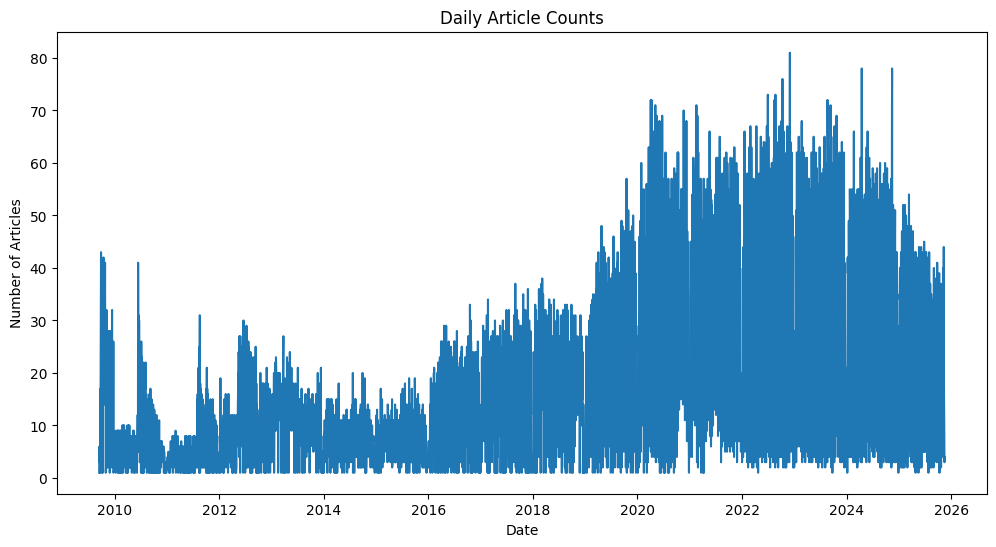

In [6]:
# Daily article counts
daily_counts = articles['date'].dt.date.value_counts().sort_index()
plt.figure(figsize=(12, 6))
daily_counts.plot()
plt.title('Daily Article Counts')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.show()

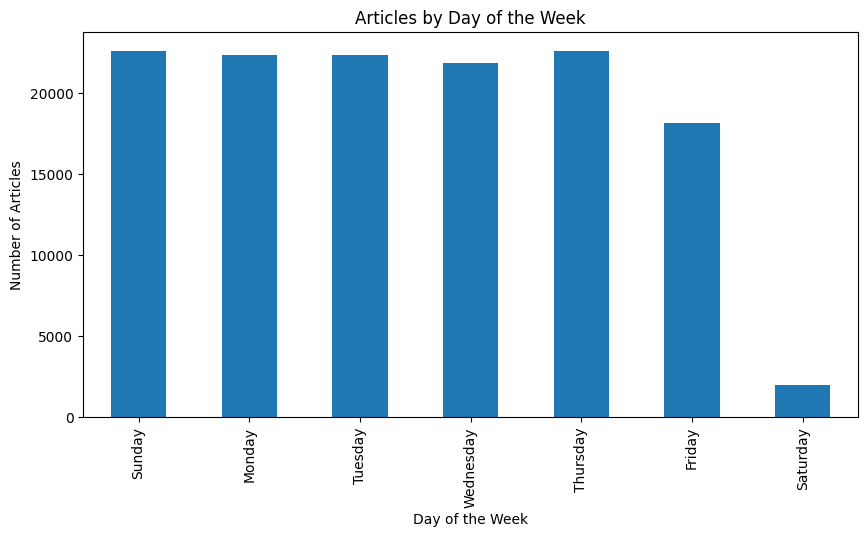

In [7]:
# Day of week analysis
articles['day_of_week'] = articles['date'].dt.day_name()
articles['day_of_week'].value_counts().plot(kind='bar',
        figsize=(10,5),
        title='Articles by Day of the Week')

# Sorting the x-axis by the order of the week
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday']

articles['day_of_week'] = pd.Categorical(articles['day_of_week'],
    categories=day_order,
    ordered=True)

articles['day_of_week'].value_counts().sort_index().plot(kind='bar',
        figsize=(10,5),
        title='Articles by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Articles')
plt.show()

/tmp/ipython-input-2261037856.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day_of_week', y='article_count', data=daily_article_counts_df, palette='viridis')


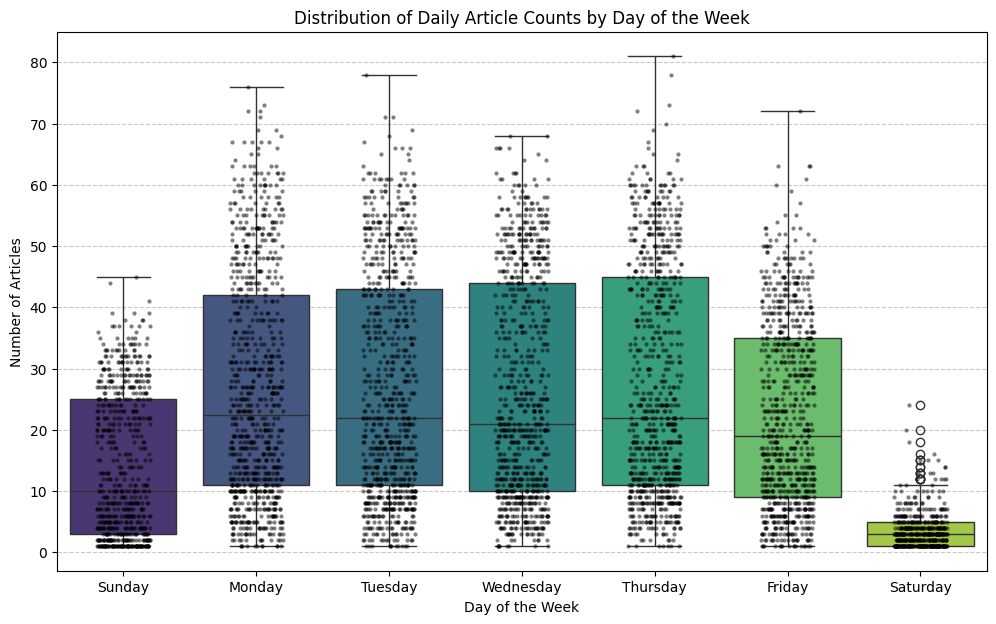

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate daily article counts
daily_article_counts_df = articles.groupby(articles['date'].dt.date).size().reset_index(name='article_count')
daily_article_counts_df['date'] = pd.to_datetime(daily_article_counts_df['date']) # Convert back to datetime for dt accessor

# Extract day of the week for each daily count
daily_article_counts_df['day_of_week'] = daily_article_counts_df['date'].dt.day_name()

# Ensure 'day_of_week' is categorical with the correct order for plotting
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
daily_article_counts_df['day_of_week'] = pd.Categorical(daily_article_counts_df['day_of_week'], categories=day_order, ordered=True)

plt.figure(figsize=(12, 7))
sns.boxplot(x='day_of_week', y='article_count', data=daily_article_counts_df, palette='viridis')
sns.stripplot(x='day_of_week', y='article_count', data=daily_article_counts_df, color='black', size=3, jitter=0.2, alpha=0.5)
plt.title('Distribution of Daily Article Counts by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Articles')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

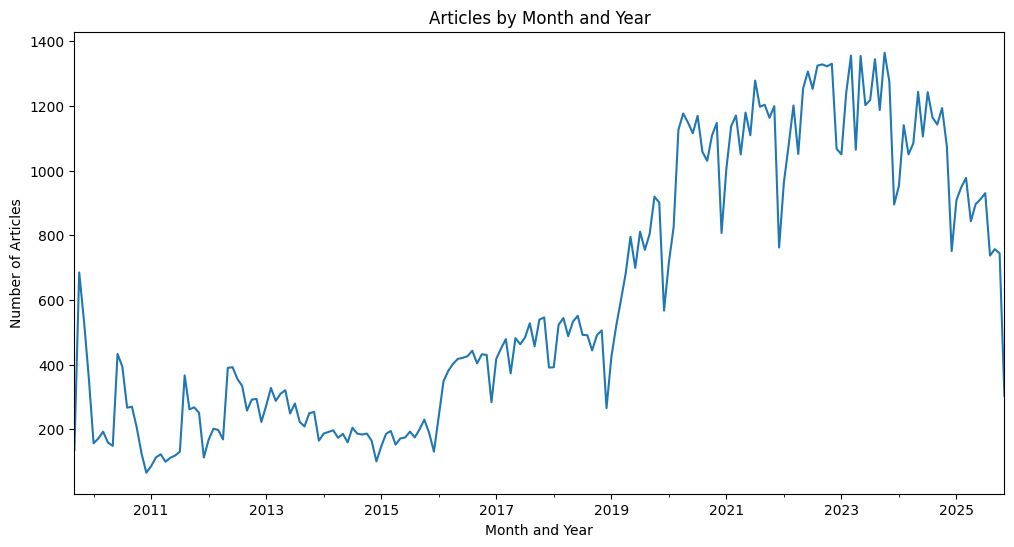

In [10]:
#1 Volume of articles by Month, year
articles['month_year'] = articles['date'].dt.to_period('M')
articles['month_year'].value_counts().sort_index().plot(
    kind='line', figsize=(12,6),
    title='Articles by Month and Year')
plt.xlabel('Month and Year')
plt.ylabel('Number of Articles')
plt.show()

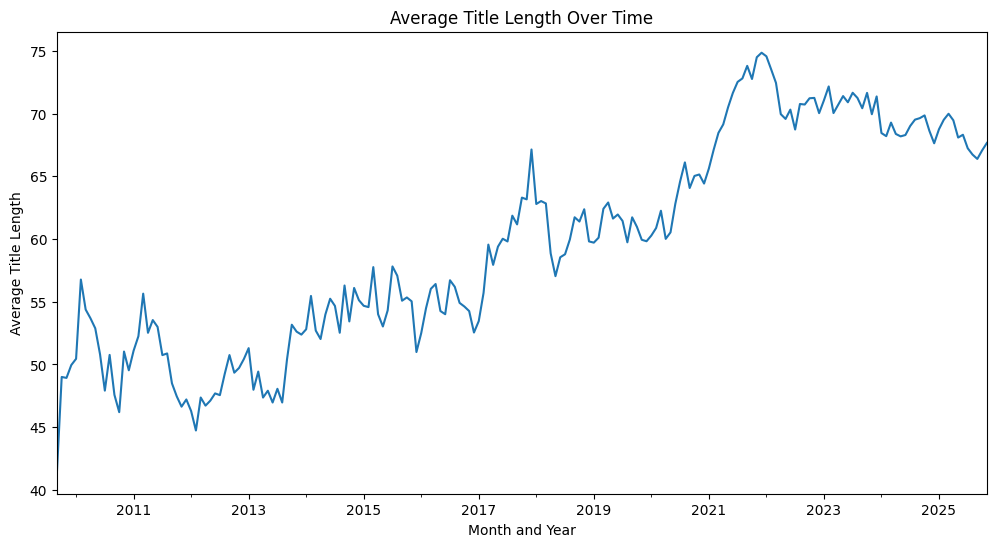

In [11]:
# Average Title Length Over Time
articles['title_length'] = articles['title'].apply(len)
avg_title_length = articles.groupby(articles['date'].dt.to_period('M'))['title_length'].mean()
avg_title_length.plot(kind='line', figsize=(12,6), title='Average Title Length Over Time')
plt.xlabel('Month and Year')
plt.ylabel('Average Title Length')
plt.show()

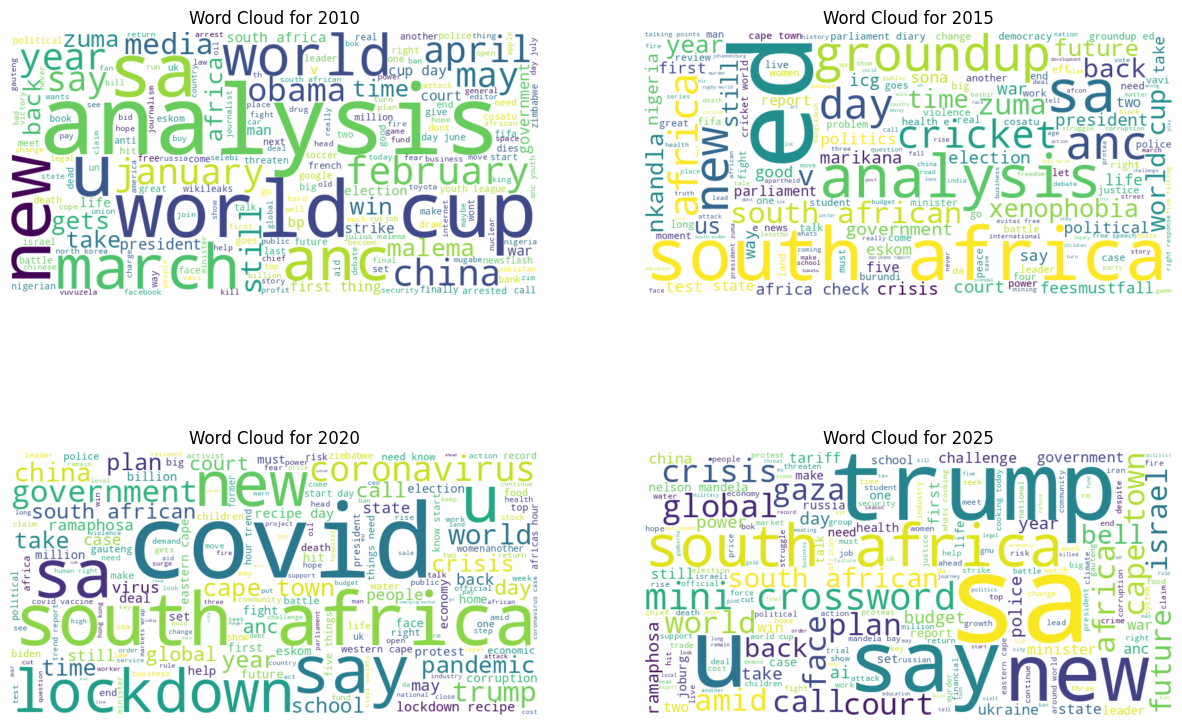

In [12]:
# Word Cloud Over Time (2009 vs 2015 vs 2020 vs 2025)
years = [2010, 2015, 2020, 2025]
plt.figure(figsize=(15,10))
for i, year in enumerate(years):
    yearly_text = ' '.join(articles[articles['date'].dt.year == year]['title_nw'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(yearly_text)
    plt.subplot(2, 2, i+1)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for {year}')
    plt.axis('off')
plt.show()

## Sentiment Analysis


In [13]:
# Transformer-Based Sentiment Scoring (FinBERT)
from transformers import pipeline

model_name = "yiyanghkust/finbert-tone"
financial_sentiment_analyzer = pipeline("sentiment-analysis", model=model_name)

# Process titles in batches for efficiency
# The pipeline expects a list of strings, and returns a list of dicts
finbert_results = financial_sentiment_analyzer(articles['title'].tolist())

# Extract labels and scores from the results
articles['finbert_label'] = [res['label'] for res in finbert_results]
articles['finbert_score'] = [res['score'] for res in finbert_results]

articles.head()

Device set to use cuda:0


,date,title,title_nw,day_of_week,month_year,title_length,finbert_label,finbert_score
0,2013-02-01,street life thats why im on the streets,street life thats im streets,Friday,2013-02,39,Neutral,0.999926
1,2013-02-01,israeli elections the bizarre payoffs of bibis...,israeli elections bizarre payoffs bibis illega...,Friday,2013-02,72,Neutral,0.985617
2,2009-10-12,chad oil pipeline threatens villages draws act...,chad oil pipeline threatens villages draws act...,Monday,2009-10,58,Negative,0.999659
3,2009-10-12,ethiopian opposition parties present common front,ethiopian opposition parties present common front,Monday,2009-10,49,Neutral,0.999949
4,2009-10-12,nigerian fuel tanker inferno engulfs minibus p...,nigerian fuel tanker inferno engulfs minibus p...,Monday,2009-10,55,Neutral,0.999964


In [14]:
articles['month_start'] = articles['month_year'].dt.to_timestamp()


# Group by month_start and finbert_label and count articles
sentiment_counts = articles.groupby(['month_start', 'finbert_label']).size().reset_index(name='count')

# Pivot the table
sentiment_pivot = sentiment_counts.pivot(index='month_start', columns='finbert_label', values='count').fillna(0)

# Calculate percentages
sentiment_pivot['total'] = sentiment_pivot.sum(axis=1)
sentiment_pivot['Positive_pct'] = (sentiment_pivot['Positive'] / sentiment_pivot['total']) * 100
sentiment_pivot['Neutral_pct'] = (sentiment_pivot['Neutral'] / sentiment_pivot['total']) * 100
sentiment_pivot['Negative_pct'] = (sentiment_pivot['Negative'] / sentiment_pivot['total']) * 100

# Display the first few rows of the prepared data
sentiment_pivot.head()


finbert_label,Negative,Neutral,Positive,total,Positive_pct,Neutral_pct,Negative_pct
month_start,,,,,,,
2009-09-01,15,115,6,136,4.411765,84.558824,11.029412
2009-10-01,101,545,39,685,5.693431,79.562044,14.744526
2009-11-01,75,417,43,535,8.037383,77.943925,14.018692
2009-12-01,46,284,30,360,8.333333,78.888889,12.777778
2010-01-01,24,123,10,157,6.369427,78.343949,15.286624


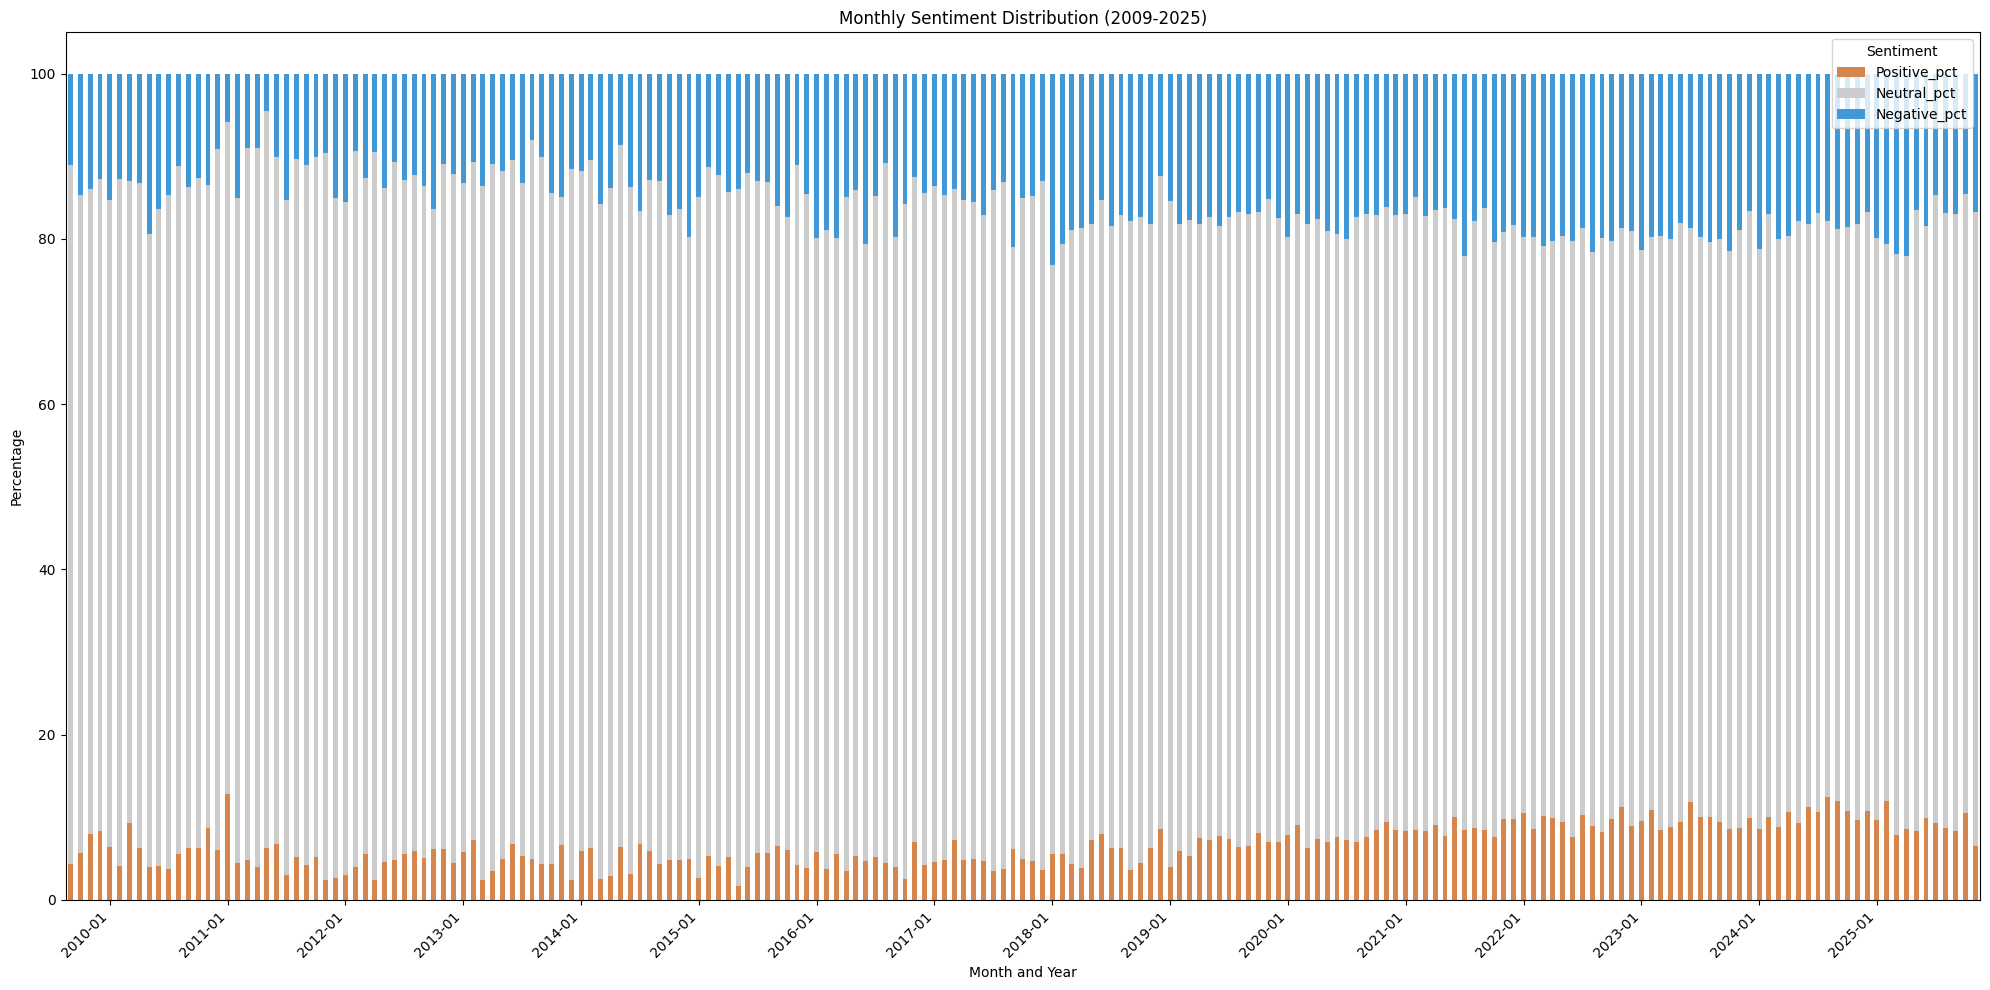

In [15]:
# sentiment hue categories
color_hues = ['#d6854c', '#cccccc','#4198d7']

ax = sentiment_pivot[['Positive_pct', 'Neutral_pct', 'Negative_pct']].plot(
    kind='bar',
    stacked=True,
    figsize=(20, 10),
    color=color_hues, # Use the custom color list
    title='Monthly Sentiment Distribution (2009-2025)'
)
plt.xlabel('Month and Year')
plt.ylabel('Percentage')
plt.legend(title='Sentiment')

# Clean up x-axis labels
# Get the positions of the monthly data points where the month is January
tick_positions = [i for i, date_idx in enumerate(sentiment_pivot.index) if date_idx.month == 1]
# Generate tick labels for these positions in 'YYYY-MM' format
tick_labels = [sentiment_pivot.index[i].strftime('%Y-%m') for i in tick_positions]

# Set the new tick positions and labels, and rotate them for better readability
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Sentiment Trend Analysis (2009-2025)

Upon analyzing the average sentiment percentages from the article headlines, a clear shift in sentiment over time can be observed:

*   **Positive Sentiment**: Increased from approximately **6.13%** in the initial period (2009-2011) to **10.20%** in the later period (2023-2025).
*   **Neutral Sentiment**: Decreased from approximately **85.06%** in the initial period to **74.23%** in the later period.
*   **Negative Sentiment**: Increased from approximately **8.81%** in the initial period to **15.57%** in the later period.

**Conclusion:**

The national mood, as reflected in the article headlines, appears to be becoming **more polarized** over time. While positive sentiment has increased, negative sentiment has also increased significantly, and neutral sentiment has decreased. This suggests that headlines are becoming less neutral and more emotionally charged, with both positive and negative tones becoming more prevalent.

## Nolvety Index over time

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Instantiate TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to 5000 features to manage dimensionality

# Apply fit_transform to the 'title_nw' column
tfidf_matrix = tfidf_vectorizer.fit_transform(articles['title_nw'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("First 5 rows of TF-IDF matrix (dense representation for viewing):")
print(tfidf_matrix[:5].toarray())

TF-IDF matrix shape: (118482, 5000)
First 5 rows of TF-IDF matrix (dense representation for viewing):
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [17]:
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
tfidf_df.head()

,abahlali,abandon,abandoned,able,abortion,abrahams,abroad,absa,absence,abuse,...,zimbabweans,zimbabwes,zondo,zone,zuckerberg,zulu,zuma,zumas,zwane,zweli
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Reasoning**:
Now that the TF-IDF vectors are in a DataFrame, I will add the 'month_year' column from the original 'articles' DataFrame to the 'tfidf_df' to prepare for monthly aggregation.



In [18]:
tfidf_df['month_year'] = articles['month_year']
tfidf_df.head()

,abahlali,abandon,abandoned,able,abortion,abrahams,abroad,absa,absence,abuse,...,zimbabwes,zondo,zone,zuckerberg,zulu,zuma,zumas,zwane,zweli,month_year
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2013-02
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2013-02
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2009-10
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2009-10
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2009-10


**Reasoning**:
With the 'month_year' column now in `tfidf_df`, I will group the DataFrame by 'month_year' and calculate the mean for all other columns (TF-IDF features) to obtain the average TF-IDF vector for each month.



In [19]:
monthly_avg_tfidf = tfidf_df.groupby('month_year').mean()
print("Shape of monthly_avg_tfidf:", monthly_avg_tfidf.shape)
monthly_avg_tfidf.head()

Shape of monthly_avg_tfidf: (195, 5000)


,abahlali,abandon,abandoned,able,abortion,abrahams,abroad,absa,absence,abuse,...,zimbabweans,zimbabwes,zondo,zone,zuckerberg,zulu,zuma,zumas,zwane,zweli
month_year,,,,,,,,,,,,,,,,,,,,,
2009-09,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.005148,0.0,0.0,0.013511,0.004151,0.0,0.0
2009-10,0.0,0.0,0.000769,0.000679,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000692,0.0,0.000000,0.0,0.0,0.006856,0.003199,0.0,0.0
2009-11,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000619,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000851,0.000000,0.0,0.0
2009-12,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.002655,0.0,0.000000,0.0,0.0,0.004062,0.000000,0.0,0.0
2010-01,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.004728,0.002311,0.0,0.0


In [20]:
from sklearn.metrics.pairwise import cosine_similarity

novelty_scores = []
month_years = []

# Iterate starting from the second month (index 1)
for i in range(1, len(monthly_avg_tfidf)):
    current_month_vector = monthly_avg_tfidf.iloc[i].values.reshape(1, -1)
    previous_month_vector = monthly_avg_tfidf.iloc[i-1].values.reshape(1, -1)

    # Calculate cosine similarity
    # Ensure vectors are not zero vectors before calculating similarity to avoid NaN
    if np.sum(current_month_vector) == 0 or np.sum(previous_month_vector) == 0:
        similarity = 0.0 # Or np.nan, depending on how you want to handle zero vectors
    else:
        similarity = cosine_similarity(current_month_vector, previous_month_vector)[0][0]

    # Calculate novelty (1 - similarity)
    novelty = 1 - similarity
    novelty_scores.append(novelty)

    # Store the month_year for the current month
    month_years.append(monthly_avg_tfidf.index[i])

# Convert to Pandas Series
monthly_novelty_index = pd.Series(novelty_scores, index=month_years)

print("Monthly Novelty Index (first 5 entries):")
print(monthly_novelty_index.head())

Monthly Novelty Index (first 5 entries):
2009-10    0.514343
2009-11    0.295461
2009-12    0.388445
2010-01    0.778223
2010-02    0.865738
Freq: M, dtype: float64


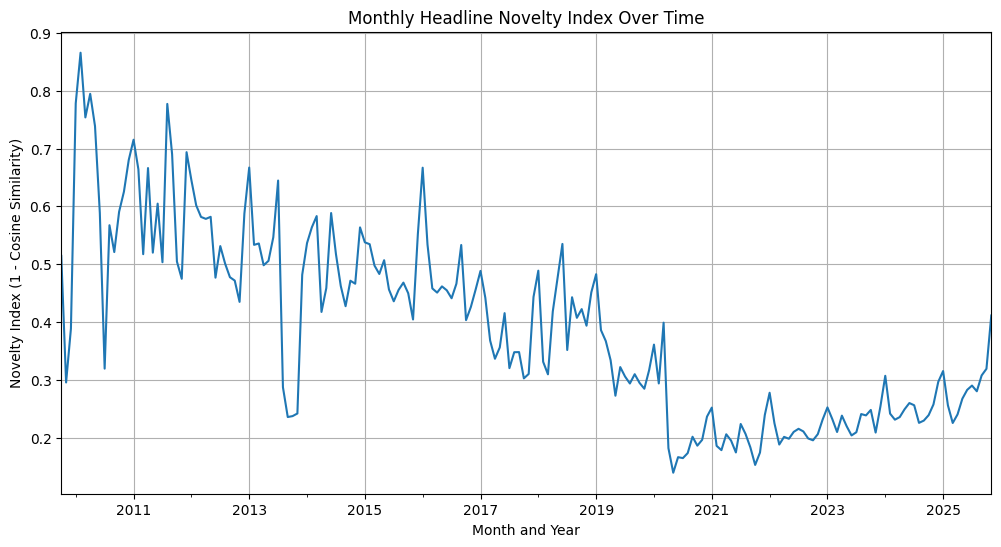

In [21]:
plt.figure(figsize=(12, 6))
monthly_novelty_index.plot(kind='line')
plt.title('Monthly Headline Novelty Index Over Time')
plt.xlabel('Month and Year')
plt.ylabel('Novelty Index (1 - Cosine Similarity)')
plt.grid(True)
plt.show()


## **1. 2009–2012 → Very High Novelty (0.6–0.85)**

This period shows **high variability and diversity** in news topics.

### What this suggests:

* The outlet was covering a **broad range of issues**.
* Headlines were **less formulaic**, more exploratory.
* Likely reflects major events such as:

  * 2010 FIFA World Cup buildup and aftermath
  * Global financial-crisis recovery
  * Early Zuma-era political dynamics

The volatility in novelty means editors were experimenting or responding to many unrelated news events.

---

## **2. 2013–2017 → Declining Novelty (0.45–0.6)**

A noticeable downward shift begins around 2013.

### What this suggests:

* The news agenda becomes **more stable and repetitive**.
* Possibly more focus on:

  * Eskom/Load shedding cycles
  * State capture saga
  * Recurring political themes
* The outlet may have shifted towards **more formulaic headline structures**, or a narrower topic set dominated the national conversation.

Still some spikes → meaning occasional unexpected crises or political shocks.

---

## **3. 2018–2020 → Clear downward trend toward lowest novelty (~0.20–0.35)**

This is the most persistent drop.

### What this suggests:

* Headlines became **very similar month to month**.
* National narrative became dominated by a few repeating themes:

  * Eskom / electricity crisis
  * Corruption inquiries (Zondo Commission)
  * Major elections (2019)
  * COVID-19 buildup late 2019 / early 2020

2020 specifically shows **a collapse in novelty**, consistent with global headlines overwhelmingly focused on COVID-19.

---

## **4. 2021–2024 → Plateau at very low novelty (~0.15–0.25)**

One of the most important insights:

### Interpretations:

* News became **extremely repetitive**—likely cyclical coverage:

  * Pandemic aftermath
  * SA economic stagnation
  * Energy crisis
  * Political uncertainty
* Editorial tone may have shifted toward short, templated headline structures.

This period may show **reader fatigue** or **agenda stagnation**.

---

## **5. 2024–2025 → Gradual Rise in Novelty (~0.20 → 0.35+)**

A slow, consistent upward trend begins.

### What this suggests:

* The outlet is beginning to cover **more diverse topics again**.
* Driven by:

  * Economic recovery themes
  * South African 2024 election cycle
  * Global geopolitical changes
  * New narratives emerging post-COVID + loadshedding relief patterns

This may reflect editorial strategy shifts or genuine diversification in global and regional events.

---

# **High-Level Editorial Insight**

**The dataset shows a long-term arc from high diversity → increasing repetition → early signs of rebound.**

This tells a compelling business story:

* **Early years:** Wide coverage and experimentation
* **Mid-2010s:** National issues dominate
* **Late 2010s–early 2020s:** Crises cause headline homogeneity
* **2024–2025:** Rebound into broader storytelling


